# `==== Atelier Seaborn ====`

### `0.4 Installation et importation de seaborn, matplotlib, pandas et numpy`

In [25]:
# terminal: pip install seaborn matplotlib pandas numpy

# Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### `0.5 Importation des mesures des capteurs`

In [26]:
df = pd.read_csv("../data/mesures_capteurs.csv")


### `0.6 Vérification du contenu du dataframe`

In [27]:
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## `Partie 0: Analyse exploratoire: ADA`

In [28]:
# Information du dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [29]:
# Vérification de la dimension
print(df.shape)
# Verification des statistiques descriptives
df.describe()

(605, 9)


,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [30]:
# Suppression des duplications
df.drop_duplicates(inplace=True)
df.shape

(600, 9)

In [7]:
# Remplissage des valeurs manquantes pour les floats:

On remarque que les colonnes `temperature`, `humidite`, `pression`, `consommation` et `etat` contiennent des valeurs manquantes.

Dans un premier temps on gere les foats:

apres analyse on remarque que l'ecart-type et la moyenne pour les colonnes de type floats sont très éloignés et il en est de même pour les min et les max: donc on remplace les valeurs manquantes par la mediane qui est moins sensible aux valeurs abérantes.

In [31]:
# colonne température
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
# Colonne consommation
df['consommation'] = df['consommation'].fillna(df['consommation'].median())
# Colonne humidite
df['humidite'] = df['humidite'].fillna(df['humidite'].median())
# Colonne pression
df['pression'] = df['pression'].fillna(df['pression'].median())
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     600 non-null    str    
 1   date_heure    600 non-null    str    
 2   id_capteur    600 non-null    str    
 3   batiment      600 non-null    str    
 4   temperature   600 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          596 non-null    str    
dtypes: float64(4), str(5)
memory usage: 46.9 KB


In [32]:
df["etat"].mode()

0    OK
Name: etat, dtype: str

In [33]:
df["etat"] = df["etat"].fillna("OK")
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     0
humidite        0
pression        0
consommation    0
etat            0
dtype: int64

## `Partie 1 – Distribution d'une variable avec histplot()`

### `1.1 Distribution des températures`

In [34]:
df["temperature"].dtype
df["temperature"].apply(type).value_counts()

temperature
<class 'float'>    600
Name: count, dtype: int64

<Axes: xlabel='temperature', ylabel='Count'>

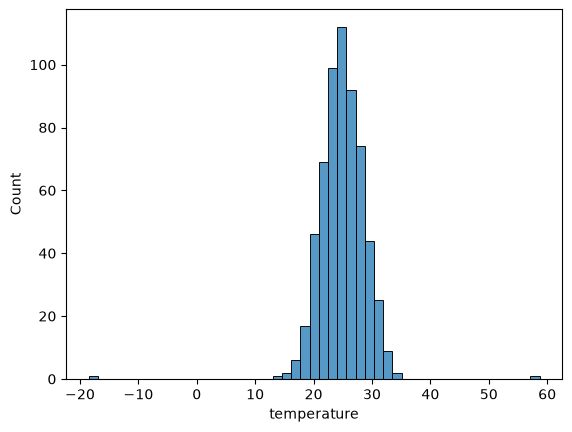

In [35]:
sns.histplot(data=df, x="temperature")
 

### `1.2 Autour de quelle valeur les températures sont concentrées ?`

La majorité des valeurs se concentrent entre 20°C et 30°C, avec un pic net
autour de 24-25°C (barre la plus haute, ~112 observations).

### ` 1.3 La distribution semble-t-elle symétrique ? `

Oui, dans sa partie centrale (15-35°C) la distribution a une forme de
cloche assez symétrique, proche d'une loi normale. Ce n'est cependant pas
parfaitement symétrique : on note une légère queue plus étalée vers les
basses valeurs (jusqu'à ~12°C) que vers les hautes.

### ` 1.4 Existe-t-il des valeurs extrêmes ? `

Oui, clairement deux outliers isolés et très éloignés du reste de la
distribution : une valeur autour de -18°C et une autre autour de 58°C.
Ces deux points sont physiquement suspects (probablement des erreurs de
capteur/saisie plutôt que de vraies mesures) et méritent d'être vérifiés
avant toute analyse plus poussée.

### ` 1.5 Modification du nombre de classes`



<Axes: xlabel='temperature', ylabel='Count'>

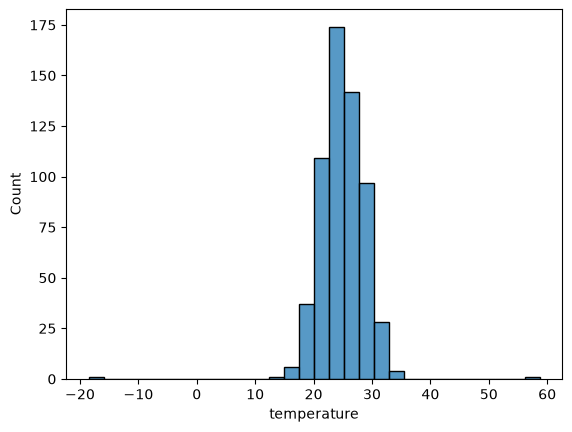

In [37]:
sns.histplot(data=df, x="temperature", bins=30)


### `1.6 la distribution des températures par bâtiment`

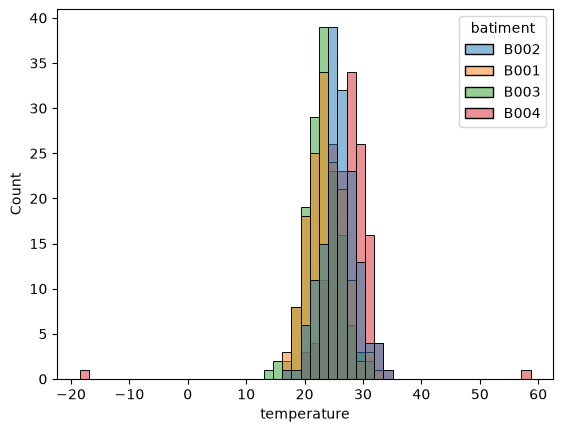

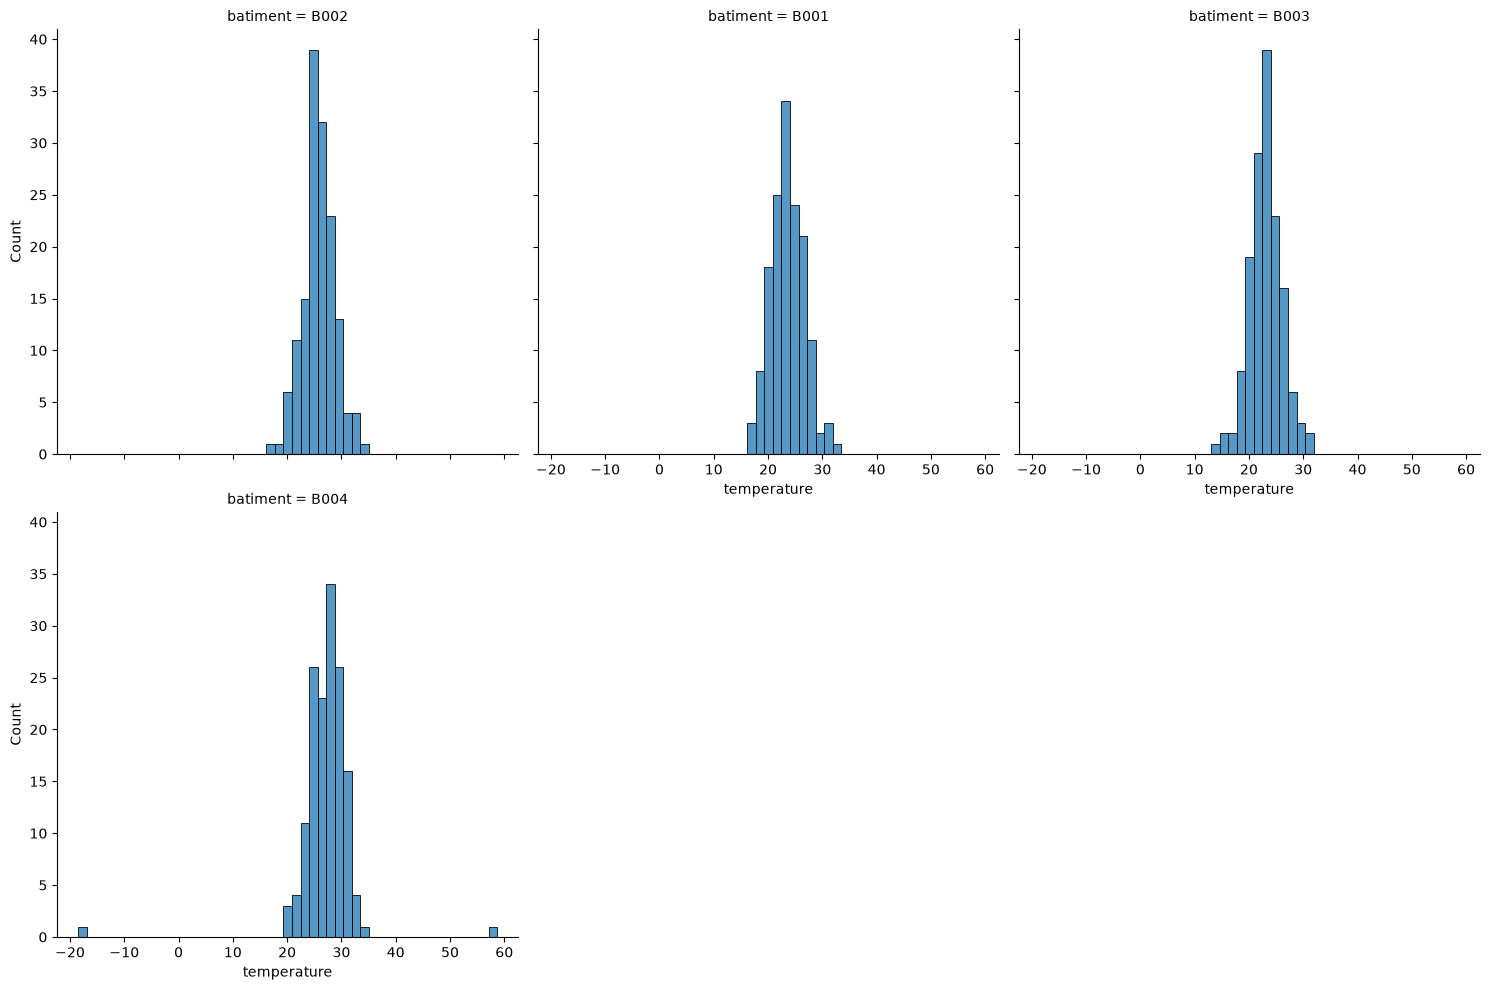

In [43]:
sns.histplot(data=df, x='temperature', hue='batiment', stat='count')
sns.displot(data=df, x='temperature', col='batiment', kind="hist", col_wrap=3)